In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
ROOT_DIR = Path("/home/artyom/myprojects/ITMO/DML/")
DATA_PATH = ROOT_DIR.joinpath("data/")
EMO_COLS = ["sentiment", "happy", "sad", "anger", "surprise", "disgust", "fear"]

In [ ]:
dfs = []
for file in list(DATA_PATH.glob("*.csv")):
    tmp_df = pd.read_csv(file)
    dfs.append(tmp_df)

df = pd.concat(dfs)
df.head(5)

,video,start_time,end_time,sentiment,happy,sad,anger,surprise,disgust,fear,text,ASR
0,-3g5yACwYnA,82.7645,100.5550,1.000000,0.666667,0.666667,0.0,0.0,0.0,0.666667,Key is part of the people that we use to solve...,key part of the people that we use the to sel...
1,-3g5yACwYnA,119.9190,125.2990,0.666667,0.000000,0.000000,0.0,0.0,0.0,0.000000,They've been able to find solutions or at leas...,is that we do they have been able to find sol...
2,-3g5yACwYnA,4.8400,13.6315,0.000000,0.666667,0.666667,0.0,0.0,0.0,0.333333,Key Polymer brings a technical aspect to our o...,creations and key brings a keep our brains ar...
3,-3g5yACwYnA,13.6315,27.0310,0.000000,0.333333,0.333333,0.0,0.0,0.0,0.000000,We're a huge user of adhesives for our operati...,we are a huge a user of adhesives for our ope...
4,-3g5yACwYnA,27.0310,41.3000,1.000000,0.666667,0.000000,0.0,0.0,0.0,0.000000,Key brings those types of aspects to a busines...,he brings those types of a aspects to our bus...


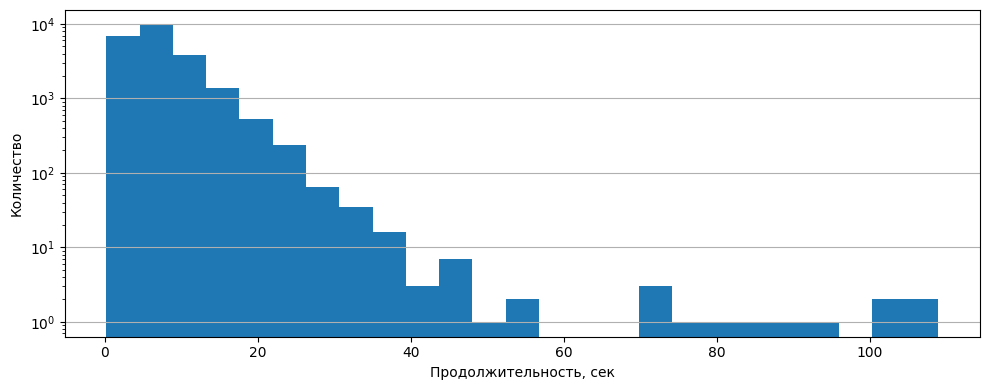

count    22797.000000
mean         7.324522
std          5.116455
min          0.189500
25%          4.082993
50%          6.188000
75%          9.215193
max        108.928571
Name: duration, dtype: float64

In [ ]:
df["duration"] = df["end_time"] - df["start_time"]

plt.figure(figsize=(10, 4))
df["duration"].plot.hist(bins=25)
plt.yscale("log")
plt.xlabel("Продолжительность, сек")
plt.ylabel("Количество")
plt.grid(True, "major", "y")
plt.tight_layout()
plt.savefig(ROOT_DIR.joinpath("imgs/duration.png"), dpi=300)
plt.show()
df["duration"].describe()

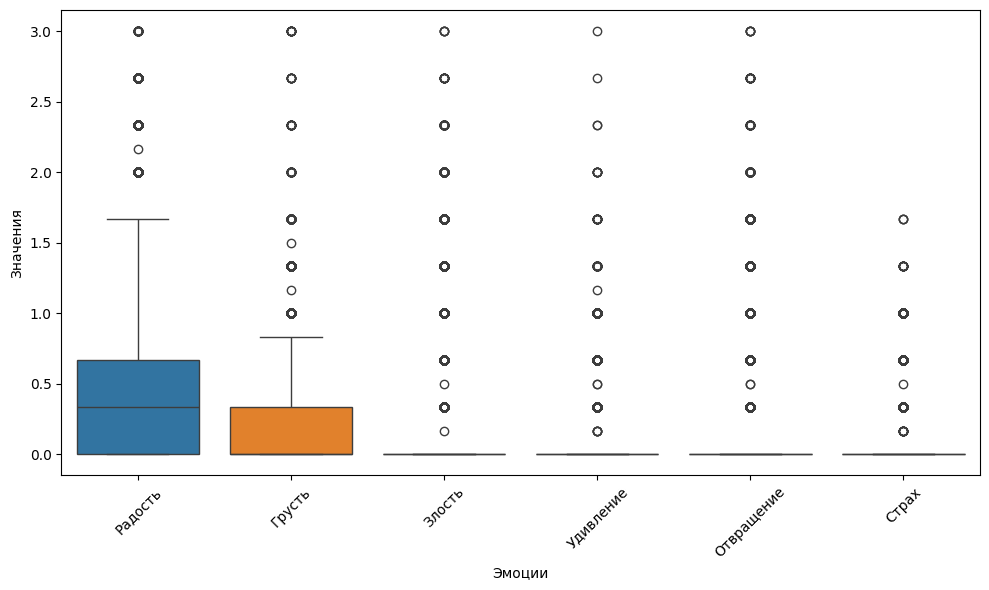

In [ ]:
df_melted = df[EMO_COLS[1:]].melt(var_name="Emotion", value_name="Value")

# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Emotion", y="Value", hue="Emotion", data=df_melted)
plt.xlabel("Эмоции")
plt.ylabel("Значения")
plt.xticks(ticks=range(6), labels=["Радость", "Грусть", "Злость", "Удивление", "Отвращение", "Страх"], rotation=45)
plt.tight_layout()
plt.savefig(ROOT_DIR.joinpath("imgs/box.png"), dpi=300)
plt.show()

In [ ]:
df["sentiment"].value_counts()

sentiment
 0.000000    4976
 0.333333    2993
 0.666667    2508
 1.000000    1881
-0.333333    1528
 1.333333    1404
-0.666667    1118
 1.666667    1009
-1.000000     883
-1.333333     828
-1.666667     756
 2.000000     737
-2.000000     647
-2.333333     411
 2.333333     396
-2.666667     279
 2.666667     206
-3.000000     126
 3.000000      61
 0.500000      11
 0.166667      11
 1.500000       8
 0.833333       7
-0.500000       4
-0.166667       3
 1.166667       3
 1.833333       2
 2.500000       1
Name: count, dtype: int64

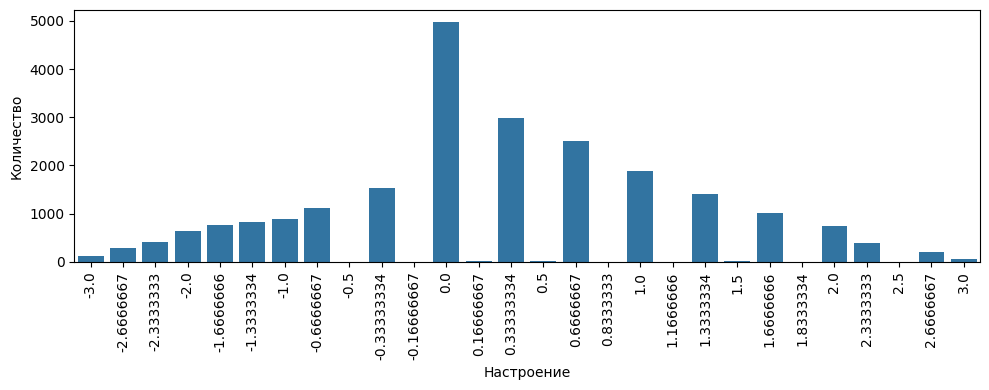

In [ ]:
plt.figure(figsize=(10, 4))
sns.countplot(x="sentiment", data=df)
plt.xlabel("Настроение")
plt.ylabel("Количество")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(ROOT_DIR.joinpath("imgs/sentiment.png"), dpi=300)
plt.show()

In [ ]:
df[EMO_COLS[1:]].describe()

,happy,sad,anger,surprise,disgust,fear
count,22797.000000,22797.000000,22797.000000,22797.000000,22797.000000,22797.000000
mean,0.479478,0.158325,0.156263,0.048003,0.120308,0.041197
std,0.628888,0.325480,0.361663,0.168300,0.320784,0.152910
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.666667,0.333333,0.000000,0.000000,0.000000,0.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,1.666667


In [ ]:
df[EMO_COLS[1:]].corr()

,happy,sad,anger,surprise,disgust,fear
happy,1.000000,-0.260575,-0.236556,0.031447,-0.205221,-0.045924
sad,-0.260575,1.000000,0.043392,0.041456,0.195739,0.130940
anger,-0.236556,0.043392,1.000000,0.039716,0.438721,-0.001570
surprise,0.031447,0.041456,0.039716,1.000000,0.137373,0.022539
disgust,-0.205221,0.195739,0.438721,0.137373,1.000000,-0.012610
fear,-0.045924,0.130940,-0.001570,0.022539,-0.012610,1.000000
